Part 1: Data Preprocessing & Feature Engineering

In [ ]:
import requests
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
import pyarrow as pa
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score, 
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint

print("All libraries imported successfully!")

All libraries imported successfully!


In [81]:
# Define URLs for required files
taxi_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Create data/raw directory if it doesn't exist
BASE_DIR = Path.cwd().resolve()
data_dir = BASE_DIR / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)

# Defines File paths for downloaded data
taxi_path = data_dir / "yellow_tripdata_2024-01.parquet"
zone_path = data_dir / "taxi_zone_lookup.csv"

# Download Files and write to specified paths
def download_file(url, path):
    if path.exists():
        return
     
    with requests.get(url, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

download_file(taxi_url, taxi_path)
download_file(zone_url, zone_path)
print("\nFiles downloaded successfully!")


Files downloaded successfully!


In [82]:
# Load Taxi Data with Polars
df = pl.read_parquet(taxi_path)

# Load Zone Lookup Data with Polars
df_zones = pl.read_csv(zone_path)

# Remove rows with nulls
def remove_nulls(df):
    num_rows = df.height

    critical_columns = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", 
                    "DOLocationID", "fare_amount"]
    
    df = df.drop_nulls(critical_columns)

    removed_nulls = num_rows - df.height
    return df, removed_nulls

# Filter out invalid trips tracking reasons for removal
def filter_trips(df):
    current_rows = df.height

    df = df.filter(pl.col("trip_distance") > 0)
    invalid_distance = current_rows - df.height
    current_rows = df.height

    df = df.filter(pl.col("fare_amount") > 0)
    negative_fare = current_rows - df.height
    current_rows = df.height

    df = df.filter(pl.col("fare_amount") <= 500)
    exceeding_max = current_rows - df.height

    return df, invalid_distance, negative_fare, exceeding_max

# Filter out trips with dropoff before pickup
def filter_time(df):
    num_rows = df.height

    df = df.filter(pl.col("tpep_dropoff_datetime") > pl.col("tpep_pickup_datetime"))

    removed_time = num_rows - df.height
    return df, removed_time

# Print summary of removals
def save_and_print(df, total_removed, removed_nulls, invalid_distance, negative_fare, exceeding_max, removed_time):
    print("\n=== Cleaned Dataset Summary ===")
    print(f"Total rows removed: {total_removed:,}")
    print(f"Removed null values: {removed_nulls:,}")
    print(f"Removed invalid distances: {invalid_distance:,}")
    print(f"Removed negative fares: {negative_fare:,}")
    print(f"Removed exceeding $500: {exceeding_max:,}")
    print(f"Removed invalid times: {removed_time:,}")

original_rows = df.height

df, removed_nulls = remove_nulls(df)
df, invalid_distance, negative_fare, exceeding_max = filter_trips(df)
df, removed_time = filter_time(df)

total_removed = original_rows - df.height

save_and_print(df, total_removed, removed_nulls, invalid_distance, negative_fare, exceeding_max, removed_time)


=== Cleaned Dataset Summary ===
Total rows removed: 95,052
Removed null values: 0
Removed invalid distances: 60,371
Removed negative fares: 34,539
Removed exceeding $500: 30
Removed invalid times: 112


In [83]:
# Filter to credit card payments only (payment_type == 1)
df = df.filter(pl.col("payment_type") == 1)
print(df.shape)

(2298347, 19)


In [84]:
# Feature Engineering - Temporal Features
df = df.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),

    # Adjusting weekday to have Monday=0, Sunday=6 by minusing 1
    (pl.col("tpep_pickup_datetime").dt.weekday() - 1).alias("pickup_day_of_week"),
])

df = df.with_columns(
    (pl.col("pickup_day_of_week") >= 5).alias("is_weekend")
)

In [85]:
# Feature Engineering - Trip Features
df = df.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60)
    .alias("trip_duration_minutes"),

    pl.col("trip_distance").log1p().alias("log_trip_distance")
])

df = df.with_columns([
    (pl.when(pl.col("trip_duration_minutes") > 0)
    .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
    .otherwise(0)
    ).alias("trip_speed_mph")
])

In [86]:
# Feature Engineering - Fare Features
df = df.with_columns([
    # Ensuring we don't divide by zero for distance by using a conditional expression
    (pl.when(pl.col("trip_distance") > 0)
    .then(pl.col("fare_amount") / pl.col("trip_distance"))
    .otherwise(0)
    ).alias("fare_per_mile"),
    
    # Ensuring we don't divide by zero for duration by using a conditional expression
    (pl.when(pl.col("trip_duration_minutes") > 0)
    .then(pl.col("fare_amount") / pl.col("trip_duration_minutes"))
    .otherwise(0)
    ).alias("fare_per_minute")
])

In [87]:
# Feature Engineering - Zone Features
# Join to get pickup borough
df = df.join(
    df_zones.select(["LocationID", "Borough"])
    .rename({
        "LocationID": "PULocationID", 
        "Borough": "pickup_borough"
    }), 
    on="PULocationID", 
    how="left"
)

# Join to get dropoff borough
df = df.join(
    df_zones.select(["LocationID", "Borough"])
    .rename({
        "LocationID": "DOLocationID", 
        "Borough": "dropoff_borough"
    }), 
    on="DOLocationID", 
    how="left"
)

# Define the Encoder to be used for both pickup and dropoff boroughs
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# One-hot encode the pickup borough columns
encoded = encoder.fit_transform(df.select("pickup_borough").to_numpy())
encoded_pickup = pl.DataFrame(encoded, 
                              schema = encoder.get_feature_names_out(["pickup_borough"])
                              .tolist())
df = df.hstack(encoded_pickup)

# One-hot encode the dropoff borough columns
encoded = encoder.fit_transform(df.select("dropoff_borough").to_numpy())
encoded_dropoff = pl.DataFrame(encoded, 
                               schema = encoder.get_feature_names_out(["dropoff_borough"])
                               .tolist())
df = df.hstack(encoded_dropoff)

print(f"\nDataFrame shape after all feature engineering: {df.shape}")
print(f"Columns: {df.columns}")


DataFrame shape after all feature engineering: (2298347, 45)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unkn

In [88]:
# Target 1: tip_amount (already a column)
# Target 2: high_tip – 1 if tip_amount > 20% of fare_amount
df = df.with_columns([
    pl.when(pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    .then(1)
    .otherwise(0)
    .alias("high_tip")
])

# Class distribution
high_tip_counts = df["high_tip"].value_counts().sort("high_tip")
print("\nhigh_tip class distribution:")
print(high_tip_counts)


high_tip class distribution:
shape: (2, 2)
┌──────────┬─────────┐
│ high_tip ┆ count   │
│ ---      ┆ ---     │
│ i32      ┆ u32     │
╞══════════╪═════════╡
│ 0        ┆ 553151  │
│ 1        ┆ 1745196 │
└──────────┴─────────┘


In [89]:
# Convert to Pandas for splitting, scaling and modeling
df = df.to_pandas()
print(df.shape)
print(f'Original Columns: {df.columns.tolist()}')

# Identify datetime columns for exclusion
datetime_cols = df.select_dtypes(include='datetime').columns.tolist()

# Identify just the pickup_borough and dropoff_borough columns for exclusion since we have already one-hot encoded them
borough_cols = ["pickup_borough", "dropoff_borough"]

df = df.drop(columns=datetime_cols + borough_cols)
print(df.shape)
print(f'Remaining Columns: {df.columns.tolist()}')

(2298347, 46)
Original Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown', 'high_tip']
(2298347, 42)
Remaini

In [90]:
# Define RANDOM_STATE for reproducibility
RANDOM_STATE = 42

target_columns = ["tip_amount", "high_tip"]

X = df.drop(columns=target_columns)
y_reg = df["tip_amount"]    # regression target
y_clf = df["high_tip"]     # classification target

# Step 1: split off training set (70 %)
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Step 2: split remaining into test (15 %) and validation (15 %)
X_test, X_val, y_reg_test, y_reg_val, y_clf_test, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_clf_temp
)

In [91]:
# Identify numeric and categorical features
numeric_features = [col for col in X.columns if X[col].dtype in ['int8', 'int32', 'int64', 'float64', 'bool']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Define numeric transformer with imputation and scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Define categorical transformer with imputation and one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'log_trip_distance', 'trip_speed_mph', 'fare_per_mile', 'fare_per_minute', 'pickup_borough_Bronx', 'pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Bronx', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']
Categorical features: ['store_and_fwd_flag']


In [92]:
# Print Number of samples in each split
print("=== Split Sizes ===")
print(f"  Train      : {X_train.shape[0]:>8,}  ({X_train.shape[0]/X.shape[0]:.1%})")
print(f"  Validation : {X_val.shape[0]:>8,}  ({X_val.shape[0]/X.shape[0]:.1%})")
print(f"  Test       : {X_test.shape[0]:>8,}  ({X_test.shape[0]/X.shape[0]:.1%})")

# Print high_tip class distribution in each split
print("\n=== high_tip Class Distribution ===")
print("\nTrain:")
print(y_clf_train.value_counts(normalize=True).sort_index())

print("\nValidation:")
print(y_clf_val.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_clf_test.value_counts(normalize=True).sort_index())

=== Split Sizes ===
  Train      : 1,608,842  (70.0%)
  Validation :  344,753  (15.0%)
  Test       :  344,752  (15.0%)

=== high_tip Class Distribution ===

Train:
high_tip
0    0.240673
1    0.759327
Name: proportion, dtype: float64

Validation:
high_tip
0    0.240674
1    0.759326
Name: proportion, dtype: float64

Test:
high_tip
0    0.240674
1    0.759326
Name: proportion, dtype: float64


In [93]:
# ===== Feature Summary =====
print("\n=== Feature Summary ===")

print(f"\nTotal features used for modeling: {len(X.columns)}")

print("\nNumeric Features:")
for col in numeric_features:
    print(f"  - {col} ({X[col].dtype})")

print("\nCategorical Features:")
for col in categorical_features:
    print(f"  - {col} ({X[col].dtype})")


# ===== Excluded Features =====
print("\n=== Excluded Features ===")

print("\nTarget Variables (excluded from X):")
for col in target_columns:
    print(f"  - {col} (target variable for prediction)")

print("\nDatetime Features:")
for col in datetime_cols:
    print(f"  - {col} (excluded because sklearn models cannot directly use datetime objects)")

print("\nCategorical Borough Features:")
for col in borough_cols:
    print(f"  - {col} (excluded because they are already one-hot encoded)")


=== Feature Summary ===

Total features used for modeling: 40

Numeric Features:
  - VendorID (int32)
  - passenger_count (int64)
  - trip_distance (float64)
  - RatecodeID (int64)
  - PULocationID (int32)
  - DOLocationID (int32)
  - payment_type (int64)
  - fare_amount (float64)
  - extra (float64)
  - mta_tax (float64)
  - tolls_amount (float64)
  - improvement_surcharge (float64)
  - total_amount (float64)
  - congestion_surcharge (float64)
  - Airport_fee (float64)
  - pickup_hour (int8)
  - pickup_day_of_week (int8)
  - is_weekend (bool)
  - trip_duration_minutes (float64)
  - log_trip_distance (float64)
  - trip_speed_mph (float64)
  - fare_per_mile (float64)
  - fare_per_minute (float64)
  - pickup_borough_Bronx (float64)
  - pickup_borough_Brooklyn (float64)
  - pickup_borough_EWR (float64)
  - pickup_borough_Manhattan (float64)
  - pickup_borough_N/A (float64)
  - pickup_borough_Queens (float64)
  - pickup_borough_Staten Island (float64)
  - pickup_borough_Unknown (float64)


Part 2: Model Training & Tuning

In [94]:
# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test sets
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed!")
print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")

Preprocessing completed!
Train shape: (1608842, 41)
Validation shape: (344753, 41)
Test shape: (344752, 41)


In [95]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_reg_train)

# Random Forest Regressor (with reduced complexity for faster training)
rf_reg = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_reg.fit(X_train_processed, y_reg_train)

print("Regression models trained successfully!")

Regression models trained successfully!


In [96]:
# ===== Regression Evaluation =====
def evaluate_regression(model, X, y_true, model_name):
    y_pred = model.predict(X)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")

# Evaluate models
evaluate_regression(lin_reg, X_val_processed, y_reg_val, "Linear Regression")
evaluate_regression(rf_reg, X_val_processed, y_reg_val, "Random Forest Regressor")


Linear Regression
MAE : 0.0748
RMSE: 0.2215
R2  : 0.9967

Random Forest Regressor
MAE : 0.9065
RMSE: 1.7950
R2  : 0.7845


In [97]:
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_processed, y_clf_train)

# Random Forest Classifier (with reduced complexity for faster training)
rf_clf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train_processed, y_clf_train)

print("Classification models trained successfully!")

Classification models trained successfully!


In [98]:
# ===== Classification Evaluation =====
def evaluate_classification(model, X, y_true, model_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

# Evaluate models
evaluate_classification(log_reg, X_val_processed, y_clf_val, "Logistic Regression")
evaluate_classification(rf_clf, X_val_processed, y_clf_val, "Random Forest Classifier")


Logistic Regression
Accuracy : 0.9959
Precision: 0.9970
Recall   : 0.9976
F1 Score : 0.9973
ROC AUC  : 0.9979

Random Forest Classifier
Accuracy : 0.8014
Precision: 0.7930
Recall   : 0.9993
F1 Score : 0.8843
ROC AUC  : 0.8630


In [99]:
# Define a straitified sample for hyperparameter tuning
sample_size = 200000

X_train_sample = X_train.sample(sample_size, random_state=RANDOM_STATE)
y_reg_train_sample = y_reg_train.loc[X_train_sample.index]
y_clf_train_sample = y_clf_train.loc[X_train_sample.index]

# Transform the sample using the already-fitted preprocessor
X_train_sample_processed = preprocessor.transform(X_train_sample)

print("Sample size for tuning:", X_train_sample.shape)

Sample size for tuning: (200000, 40)


In [100]:
# ===== Random Forest Regressor Hyperparameter Search =====
rf_regressor = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.3,
    max_depth=20
)

param_dist_reg = {
    "n_estimators": randint(80, 100),
    "max_depth": [15, 20],
    "min_samples_leaf": randint(3, 5),
}

# Document the hyperparameter search space
search_space = {
    "n_estimators": "randint(80, 100)",
    "max_depth": [15, 20],
    "min_samples_leaf": "randint(3, 5)"
}

rf_reg_search = RandomizedSearchCV(
    rf_regressor,
    param_distributions=param_dist_reg,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg_search.fit(X_train_sample_processed, y_reg_train_sample)

print("\nHyperparameter Search Spaace:", search_space)

print("\nBest Parameters:", rf_reg_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Hyperparameter Search Spaace: {'n_estimators': 'randint(80, 100)', 'max_depth': [15, 20], 'min_samples_leaf': 'randint(3, 5)'}

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 90}


In [101]:
# ===== Train Tuned Random Forest Regressor =====
best_rf_reg = rf_reg_search.best_estimator_

best_rf_reg.fit(X_train_processed, y_reg_train)

evaluate_regression(best_rf_reg, X_val_processed, y_reg_val, "Tuned Random Forest Regressor")


Tuned Random Forest Regressor
MAE : 0.5403
RMSE: 1.3431
R2  : 0.8794


In [102]:
# Compute metrics for baseline
y_pred_baseline = rf_reg.predict(X_val_processed)
mae_baseline = mean_absolute_error(y_reg_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_reg_val, y_pred_baseline))
r2_baseline = r2_score(y_reg_val, y_pred_baseline)

# Compute metrics for tuned RF
y_pred_tuned = best_rf_reg.predict(X_val_processed)
mae_tuned = mean_absolute_error(y_reg_val, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_reg_val, y_pred_tuned))
r2_tuned = r2_score(y_reg_val, y_pred_tuned)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],
    "MAE": [mae_baseline, mae_tuned],
    "RMSE": [rmse_baseline, rmse_tuned],
    "R2": [r2_baseline, r2_tuned]
})

print(comparison)

         Model       MAE      RMSE        R2
0  Baseline RF  0.906534  1.794987  0.784513
1     Tuned RF  0.540347  1.343095  0.879355


In [ ]:
# Converting training data to PyTorch tensors
if hasattr(X_train_processed, "tocoo"):
    coo = X_train_processed.tocoo()
    X_train_tensor = torch.sparse_coo_tensor(
        torch.LongTensor([coo.row, coo.col]),
        torch.FloatTensor(coo.data),
        coo.shape
    )
else:
    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)

if hasattr(X_val_processed, "tocoo"):
    coo = X_val_processed.tocoo()
    X_val_tensor = torch.sparse_coo_tensor(
        torch.LongTensor([coo.row, coo.col]),
        torch.FloatTensor(coo.data),
        coo.shape
    )
else:
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)

# Convert test set to PyTorch tensor
if hasattr(X_test_processed, "tocoo"):
    coo = X_test_processed.tocoo()
    X_test_tensor = torch.sparse_coo_tensor(
        torch.LongTensor([coo.row, coo.col]),
        torch.FloatTensor(coo.data),
        coo.shape
    )
else:
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_reg_train.values, dtype=torch.float32).view(-1,1)
y_val_tensor = torch.tensor(y_reg_val.values, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers=4, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=2048, num_workers=4, pin_memory=False)

In [104]:
# Defining the Neural Network
class TipPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

    def forward(self,x):
        return self.model(x)


input_dim = X_train_tensor.shape[1]

model = TipPredictor(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [105]:
# Training the Neural Network
epochs = 20

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 3.2551 | Val Loss: 0.2638
Epoch 2/20 | Train Loss: 0.2884 | Val Loss: 0.0737
Epoch 3/20 | Train Loss: 0.0669 | Val Loss: 0.1354
Epoch 4/20 | Train Loss: 0.0537 | Val Loss: 0.0484
Epoch 5/20 | Train Loss: 0.0680 | Val Loss: 0.0590
Epoch 6/20 | Train Loss: 0.0440 | Val Loss: 0.0503
Epoch 7/20 | Train Loss: 0.0444 | Val Loss: 0.0879
Epoch 8/20 | Train Loss: 0.0368 | Val Loss: 0.0315
Epoch 9/20 | Train Loss: 0.0340 | Val Loss: 0.0331
Epoch 10/20 | Train Loss: 0.0297 | Val Loss: 0.0367
Epoch 11/20 | Train Loss: 0.0317 | Val Loss: 0.0339
Epoch 12/20 | Train Loss: 0.0281 | Val Loss: 0.0321
Epoch 13/20 | Train Loss: 0.0259 | Val Loss: 0.0371
Epoch 14/20 | Train Loss: 0.0225 | Val Loss: 0.0270
Epoch 15/20 | Train Loss: 0.0281 | Val Loss: 0.0556
Epoch 16/20 | Train Loss: 0.0269 | Val Loss: 0.0247
Epoch 17/20 | Train Loss: 0.0200 | Val Loss: 0.0293
Epoch 18/20 | Train Loss: 0.0299 | Val Loss: 0.0258
Epoch 19/20 | Train Loss: 0.0237 | Val Loss: 0.0286
Epoch 20/20 | Train L

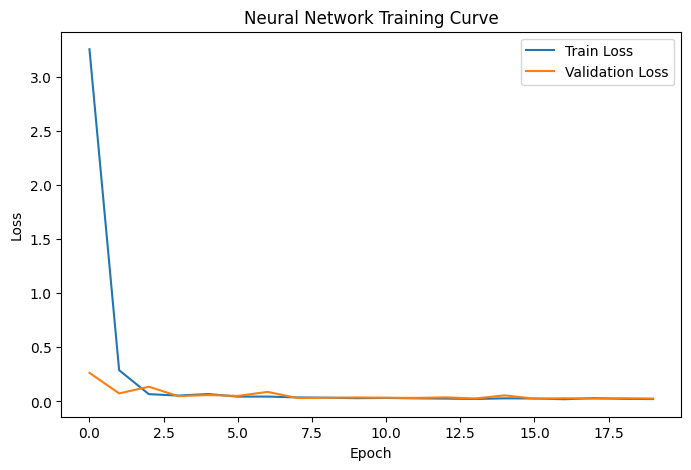

In [106]:
# Plotting Training curves
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training Curve")

plt.legend()
plt.show()

In [107]:
# Neural Network Evaluation
model.eval()

with torch.no_grad():
    y_pred_nn = model(X_val_tensor).numpy().flatten()

mae_nn = mean_absolute_error(y_reg_val, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_reg_val, y_pred_nn))
r2_nn = r2_score(y_reg_val, y_pred_nn)

print("Neural Network Performance")
print("MAE :", mae_nn)
print("RMSE:", rmse_nn)
print("R2  :", r2_nn)

Neural Network Performance
MAE : 0.0304854845442234
RMSE: 0.1625103121857946
R2  : 0.9982337203689681


Part 3: Model Evaluation & Interpretation

In [ ]:
# Preprocess test set
X_test_processed = preprocessor.transform(X_test)

# Regression predictions
lin_pred_test = lin_reg.predict(X_test_processed)
rf_pred_test = best_rf_reg.predict(X_test_processed)

# Classification predictions
log_pred_test = log_reg.predict(X_test_processed)
rf_clf_pred_test = rf_clf.predict(X_test_processed)

In [ ]:
summary = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest Regressor",
        "Neural Network"
    ],

    "MAE":[
        mean_absolute_error(y_reg_test, lin_pred_test),
        mean_absolute_error(y_reg_test, rf_pred_test),
        mean_absolute_error(y_reg_test, model(X_test_tensor).detach().numpy())
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_reg_test, lin_pred_test)),
        np.sqrt(mean_squared_error(y_reg_test, rf_pred_test)),
        np.sqrt(mean_squared_error(y_reg_test, model(X_test_tensor).detach().numpy()))
    ],

    "R2":[
        r2_score(y_reg_test, lin_pred_test),
        r2_score(y_reg_test, rf_pred_test),
        r2_score(y_reg_test, model(X_test_tensor).detach().numpy())
    ]

})

summary

In [ ]:
log_probs = log_reg.predict_proba(X_test_processed)[:,1]
rf_probs = rf_clf.predict_proba(X_test_processed)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_clf_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_clf_test, rf_probs)

plt.figure(figsize=(7,5))

plt.plot(fpr_log,tpr_log,label="Logistic Regression")
plt.plot(fpr_rf,tpr_rf,label="Random Forest")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
cm = confusion_matrix(y_clf_test, rf_clf_pred_test)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_reg_test, rf_pred_test, alpha=0.3)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")

plt.title("Predicted vs Actual Tips")

plt.show()

In [ ]:
residuals = y_reg_test - rf_pred_test

plt.hist(residuals,bins=50)

plt.title("Residual Distribution")

plt.show()


plt.scatter(rf_pred_test,residuals,alpha=0.3)

plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted")

plt.show()

In [ ]:
importances = best_rf_reg.feature_importances_

feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature":feature_names,
    "importance":importances
})

feat_imp = feat_imp.sort_values("importance",ascending=False).head(20)

plt.figure(figsize=(8,6))

plt.barh(feat_imp["feature"],feat_imp["importance"])

plt.gca().invert_yaxis()

plt.title("Top Feature Importances")

plt.show()

In [ ]:
coefficients = pd.DataFrame({

    "feature":preprocessor.get_feature_names_out(),
    "coefficient":lin_reg.coef_

})

coefficients.sort_values("coefficient",ascending=False).head(10)